<a href="https://colab.research.google.com/github/impactlabsacademy1/Cybersecurity/blob/main/ImpactLabsCopy_cybersecurity_app.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python Primer for ML: A Beginner’s Guide

**Artificial Intelligence (AI**) is the broad field of creating computer systems that can perform tasks that typically require human intelligence.

**Machine Learning** is a subfield of AI that focuses on enabling systems to learn from data without explicit programming.

**Deep Learning** is a specialized subfield within Machine Learning that uses artificial neural networks with multiple layers to learn complex patterns from large datasets.

**STEPS IN BUILDING A MACHINE LEARNING MODEL**

1.   **Data Collection** - Some sources: Public online datasets, Kaggle, etc.
2.   **Data Preprocessing** - Check for missing data and use interpolation to fill missing values, if possible; Outlier detection; Data filtering and sampling; Data integration (Handle different types of structured data such as numeric measurements, and unstructured data such as text and images); Data normalization, if needed.
1.   **Feature Extraction** - Features are the columns in a dataset. Sometimes, data is just images and we have to extract features such as color, shape etc. from images to represent them as numerical features. If the data is a signal like an ECG, we can extract statistical features (mean, median), non-linear features (entropy etc.)
2.   **Feature Selection** - Using heatmap and correlation functions, we check which features are most important and well correlated with the target label (usually the last column in a dataset) and select only those features for model building. Main goal is to eliminate irrelevant and repetitive features so complexity of models is low.
1.   **Model Training & Testing** - The goal of the AI model is to learn associations between the input features and the corresponding known target outcome (eg. biopsy results) so that the learned associations could be used to predict the actual outcome of a new dataset. This learning process is called training the classifier. There are several ways to do this. Most common ways are supervised and unsupervised learning. This file gives you an example of supervised learning where inputs and the outputs are clearly identified, and algorithms are trained using labeled examples. Classification algorithms use discrete labels/categories, and regression models use real values.

Steps for model training:
*   Check for class imbalance and balance if possible
*   Split the dataset into training and test sets
*   Use training dataset to fit the model
*   Use test dataset to test the model


# **STEP 1: Data Collection**

**DOWNLOAD DATASET**

The stroke dataset is from here: https://www.kaggle.com/datasets/mahatiratusher/stroke-risk-prediction-dataset-v2

Look for the download symbol and download it to your local drive first

**IMPORT STATEMENTS**

In [2]:
# Import statements
# These libraries are like your toolkit for data science & ML

import pandas as pd               # For handling data tables (dataframes)
import numpy as np                # For number crunching and arrays
import seaborn as sns             # For data visualization
import matplotlib.pyplot as plt   # For data visualization

# Data Resampling
from sklearn.model_selection import train_test_split

# 1. Logistic Regression
from sklearn.linear_model import LogisticRegression

# 2. K-Nearest Neighbors (KNN)
from sklearn.neighbors import KNeighborsClassifier

# 3. Decision Tree
from sklearn.tree import DecisionTreeClassifier

# 4. Random Forest
from sklearn.ensemble import RandomForestClassifier

# 5. Support Vector Machine (SVM)
from sklearn.svm import SVC

# 6. Naive Bayes
from sklearn.naive_bayes import GaussianNB

# 7. Gradient Boosting (GBM)
from sklearn.ensemble import GradientBoostingClassifier

# 8. XGBoost
from xgboost import XGBClassifier

# 9. MLP Neural Network (Multi-Layer Perceptron)
from sklearn.neural_network import MLPClassifier

# Performance Measures
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**UPLOADING THE DATASET**

In [3]:
# Use this if you want to load the dataset from your computer
from google.colab import files
uploaded = files.upload()

Saving PhiUSIIL_Phishing_URL_Dataset.csv to PhiUSIIL_Phishing_URL_Dataset.csv


**READING THE DATASET**

In [4]:
# Read the CSV file (We assumed that the downloaded dataset is a CSV file; Make sure the name matches!
df = pd.read_csv("PhiUSIIL_Phishing_URL_Dataset.csv")  # replace with actual filename

# **STEP 2: Data Preprocessing**

**UNDERSTANDING THE DATASET**

In [5]:
# Look at the first few rows
df.head()  # Shows the top 5 rows of the data

,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,...,0,0,1,34,20,28,119,0,124,1
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,...,0,0,1,50,9,8,39,0,217,1
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,...,0,0,1,10,2,7,42,2,5,1
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,...,1,1,1,3,27,15,22,1,31,1
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,...,1,0,1,244,15,34,72,1,85,1


In [ ]:
# Check how many rows and columns
df.shape  # (rows, columns)

(235795, 55)

In [6]:
# See basic info: column names, data types, and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 55 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   URL                         235795 non-null  object 
 1   URLLength                   235795 non-null  int64  
 2   Domain                      235795 non-null  object 
 3   DomainLength                235795 non-null  int64  
 4   IsDomainIP                  235795 non-null  int64  
 5   TLD                         235795 non-null  object 
 6   URLSimilarityIndex          235795 non-null  float64
 7   CharContinuationRate        235795 non-null  float64
 8   TLDLegitimateProb           235795 non-null  float64
 9   URLCharProb                 235795 non-null  float64
 10  TLDLength                   235795 non-null  int64  
 11  NoOfSubDomain               235795 non-null  int64  
 12  HasObfuscation              235795 non-null  int64  
 13  NoOfObfuscated

In [ ]:
# Summary statistics for numeric columns
df.describe()

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
count,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,...,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000
mean,34.573095,21.470396,0.002706,78.430778,0.845508,0.260423,0.055747,2.764456,1.164758,0.002057,...,0.237007,0.023474,0.486775,26.075689,6.333111,10.522305,65.071113,2.377629,49.262516,0.571895
std,41.314153,9.150793,0.051946,28.976055,0.216632,0.251628,0.010587,0.599739,0.600969,0.045306,...,0.425247,0.151403,0.499826,79.411815,74.866296,22.312192,176.687539,17.641097,161.027430,0.494805
min,13.000000,4.000000,0.000000,0.155574,0.000000,0.000000,0.001083,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,0.000000,57.024793,0.680000,0.005977,0.050747,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,27.000000,20.000000,0.000000,100.000000,1.000000,0.079963,0.057970,3.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,8.000000,2.000000,6.000000,12.000000,0.000000,10.000000,1.000000
75%,34.000000,24.000000,0.000000,100.000000,1.000000,0.522907,0.062875,3.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,29.000000,8.000000,15.000000,88.000000,1.000000,57.000000,1.000000
max,6097.000000,110.000000,1.000000,100.000000,1.000000,0.522907,0.090824,13.000000,10.000000,1.000000,...,1.000000,1.000000,1.000000,8956.000000,35820.000000,6957.000000,27397.000000,4887.000000,27516.000000,1.000000


**CHECK FOR MISSING DATA**

In [ ]:
# Count missing values in each column
df.isnull().sum()

,0
FILENAME,0
URL,0
URLLength,0
Domain,0
DomainLength,0
IsDomainIP,0
TLD,0
URLSimilarityIndex,0
CharContinuationRate,0
TLDLegitimateProb,0


**CHECK FOR OUTLIERS**

In [13]:
# Check for outliers

# Select only numeric columns (exclude categorical)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Plot boxplots for all numeric features
# plt.figure(figsize=(10, 5))  # Adjust figure size
# sns.boxplot(data=df[numeric_cols], orient="h")  # Horizontal boxplots
# plt.title("Box Plots for All Numeric Features")
# plt.show()


In [14]:
df[numeric_cols]

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,31,24,0,100.000000,1.000000,0.522907,0.061933,3,1,0,...,0,0,1,34,20,28,119,0,124,1
1,23,16,0,100.000000,0.666667,0.032650,0.050207,2,1,0,...,0,0,1,50,9,8,39,0,217,1
2,29,22,0,100.000000,0.866667,0.028555,0.064129,2,2,0,...,0,0,1,10,2,7,42,2,5,1
3,26,19,0,100.000000,1.000000,0.522907,0.057606,3,1,0,...,1,1,1,3,27,15,22,1,31,1
4,33,26,0,100.000000,1.000000,0.079963,0.059441,3,1,0,...,1,0,1,244,15,34,72,1,85,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235790,29,22,0,100.000000,1.000000,0.522907,0.058739,3,1,0,...,1,0,1,51,7,21,187,2,191,1
235791,28,21,0,100.000000,0.785714,0.028555,0.053834,2,2,0,...,1,0,0,50,1,7,88,0,31,1
235792,30,23,0,100.000000,1.000000,0.003319,0.063093,2,1,0,...,0,0,1,27,10,30,58,2,67,1
235793,55,47,0,28.157537,0.465116,0.000961,0.050211,3,2,0,...,0,0,0,0,0,3,0,0,0,0


# **STEPS 3/4: Feature Extraction/Selection**
In this example, features are already extracted and present in columns; So no need for feature extraction

In [15]:
# Drop any duplicate columns
df.drop_duplicates(inplace=True)

(235795, 51)


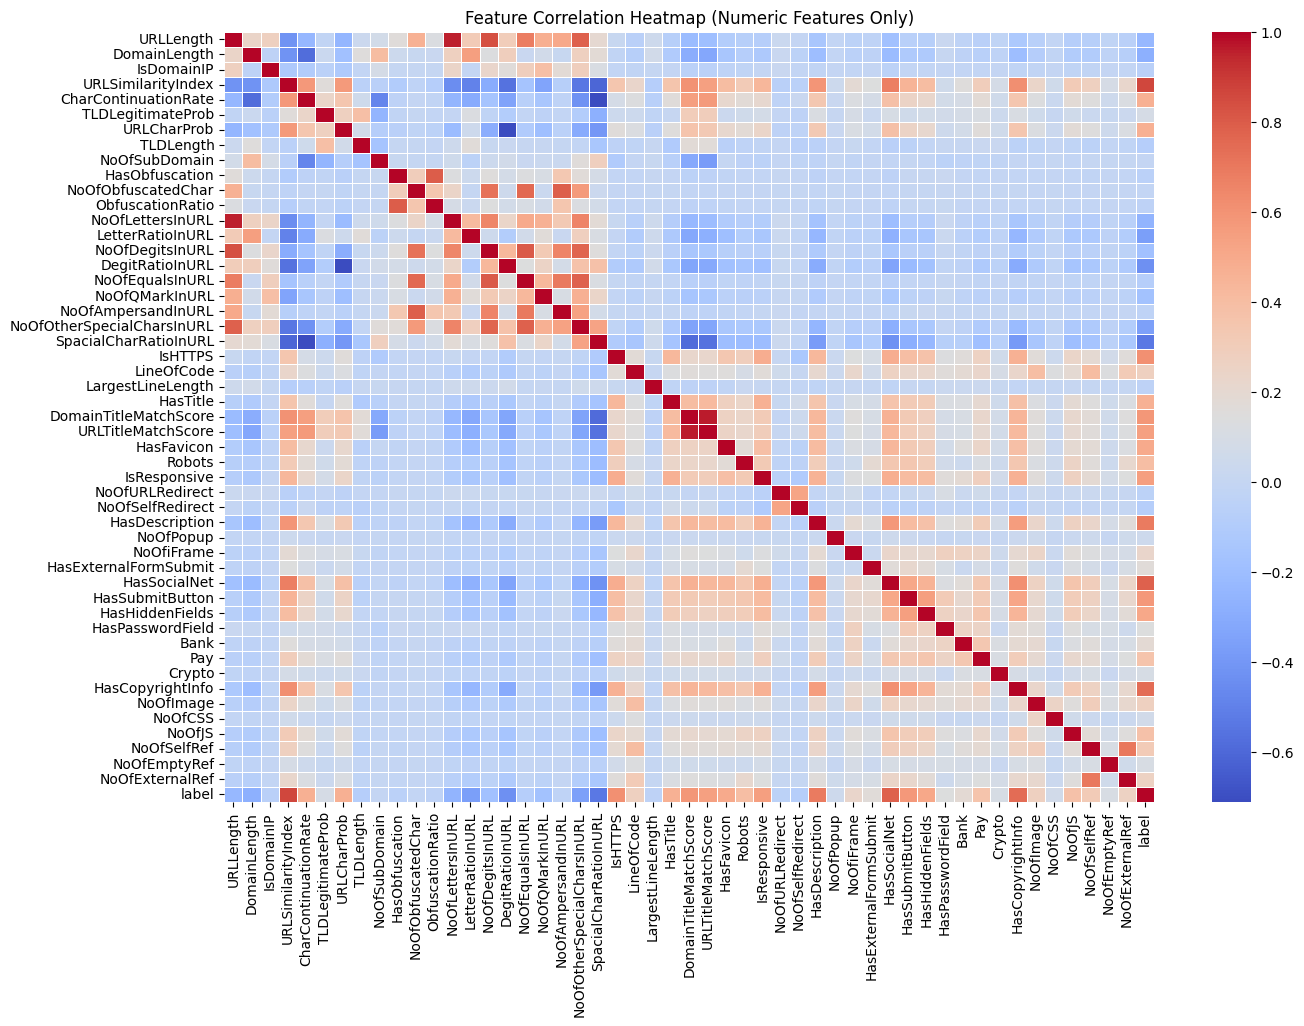

In [16]:
# Use the Feature correlation heatmap to understand which features are highly correlated with the target label
# We must select only numeric columns to avoid the 'could not convert string to float' error
plt.figure(figsize=(15, 10))

# select_dtypes(include=[np.number]) ensures we only try to correlate numbers, not strings like filenames or URLs
numeric_df = df.select_dtypes(include=[np.number])
print(numeric_df.shape)

sns.heatmap(numeric_df.corr(), annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap (Numeric Features Only)")
plt.show()

# In this example, we will keep it simple, and keep all features.
# Note: Correlation requires numerical data; object/string columns are ignored here.

**Dropping all columns that have correlation less than +/- 0.5** Store the result in df_filtered and use this for all further steps

In [17]:
# Assume df is your DataFrame and 'target' is your target column
target_col = 'label'

# Get correlation of all features with the target
correlations = df[numeric_cols].corr()[target_col]

# Find columns to keep: absolute correlation >= 0.5 (always keep target itself)
cols_to_keep = correlations[abs(correlations) >= 0.5].index.tolist()

# Filter the DataFrame
df_filtered = df[cols_to_keep]
df_filtered

,URLSimilarityIndex,SpacialCharRatioInURL,IsHTTPS,DomainTitleMatchScore,URLTitleMatchScore,IsResponsive,HasDescription,HasSocialNet,HasSubmitButton,HasHiddenFields,HasCopyrightInfo,label
0,100.000000,0.032,1,0.000000,0.000000,1,0,0,1,1,1,1
1,100.000000,0.087,1,55.555556,55.555556,0,0,1,1,0,1,1
2,100.000000,0.069,1,46.666667,46.666667,1,1,0,1,1,1,1
3,100.000000,0.038,1,0.000000,0.000000,1,0,1,1,1,1,1
4,100.000000,0.030,1,100.000000,100.000000,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
235790,100.000000,0.034,1,100.000000,100.000000,1,1,1,1,1,1,1
235791,100.000000,0.071,1,0.000000,0.000000,1,1,1,1,1,0,1
235792,100.000000,0.033,1,100.000000,100.000000,1,1,1,1,0,1,1
235793,28.157537,0.091,1,0.000000,0.000000,1,0,0,1,1,0,0


# **STEPS 5/6: MODEL TRAINING & TESTING**
Steps for model training:
*   Check for class imbalance and balance if possible
*   Split the dataset into training and test sets
*   Use training dataset to fit the model
*   Use test dataset to test the model

In [18]:
# Check for class imbalance - Is the target variable balanced? Are there similar % of positive and negative cases?
df_filtered['label'].value_counts()/len(df_filtered)

,count
label,
1,0.571895
0,0.428105


In [21]:
# PREPARE THE DATASET
# Capture the feature columns in X and the target variable in y
X = df_filtered.drop(columns=['label'])
y = df_filtered['label']

In [22]:
X.shape

(235795, 11)

In [23]:
y.shape

(235795,)

In [24]:
# Split data into 80% training and 20% testing - Hold out technique!

# Here, we are splitting our data into training and test sets:
# 1. With the 'train_test_split' function, we divide the feature set (X) and target set (y) as 80% training (X_train and y_train) and 20% test data (X_test and y_test).
# Meaning, it randomly picks 80% of the rows and makes it training dataset (X_train and y_train). It takes the remaining 20% and makes it test dataset (X_test and y_test).
# 2. The 'random_state=42' parameter ensures that the split is done the same way each time, allowing for reproducibility of results.
# 3. The 'train_size=0.8' parameter specifies that the training set will contain 80% of the total data, and the test set will contain 20%.
# 4. 'stratified=y' ensures that the class distribution (e.g., stroke vs no stroke) is preserved in both the training and test sets. This is very important for imbalanced datasets like stroke prediction.
# This step is necessary to create the datasets that will be used in the training and testing phases of the model.
# The training set allows the model to learn, while the test set helps us evaluate the model's performance.
# This is the most simple build sampling technique. It is called the hold-out technique.
# Models built using this method may not always be the most generalizable one (meaning they may not perform well when unseen test data are used)
# WHY?
# The outcome of the model can depend heavily on how the data was split. One split might give a high accuracy, another a low one. Which one to trust?
# If the split isn't representative (e.g., one class is overrepresented in one split), model evaluation may be inaccurate.
# With limited training data (especially in small datasets), the model may not learn well as there are not enough number of representative samples → UNDERFITTING
# If the test set is too small, evaluation may be overly optimistic or pessimistic → OVERFITTING risk
# Overfitting occurs when a model learns the training data too well, including its noise and outliers. It performs very well on training data but poorly on new (test) data.
# There are other advanced ways to split data for training and testing. We can cover that later.

X_new, X_val, y_new, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Split X_new into Train/Validation/Test of 60/20/20
X_train, X_test, y_train, y_test = train_test_split(X_new, y_new, test_size=0.20, random_state=42, stratify=y_new)


In [ ]:
# Remember X means features, y means target label. X_train means the features of the training dataset, y_train is the targets of the training dataset
X_train.shape

(150908, 11)

In [ ]:
y_train.shape

(150908,)

In [ ]:
y_train.value_counts()/len(y_train)

,count
label,
1,0.571898
0,0.428102


In [ ]:
# Remember X means features, y means target label. X_test means the features of the test dataset, y_test is the targets of the test dataset
X_test.shape

(37728, 11)

In [ ]:
y_test.shape

(37728,)

In [ ]:
y_test.value_counts()/len(y_test)

,count
label,
1,0.571883
0,0.428117


In [ ]:
X_val.shape

(47159, 11)

In [ ]:
y_val.shape

(47159,)

In [ ]:
y_val.value_counts()/len(y_val)

,count
label,
1,0.571895
0,0.428105


In [25]:
# Define a function that can be called to calculate the performance metrics of the model during training and testing

def evaluate_classification_model(y_target, y_predicted):
  """
  Calculates and displays the confusion matrix and performance metrics
  (Accuracy, Sensitivity, Specificity) for a classification model.

  Args:
    y_target: The true target values (ground truth).
    y_predicted: The predicted values from the model.
  """

  # A confusion matrix is used to evaluate the performance of a classification model. For binary classification, it includes:

  #                    Predicted Positive	  Predicted Negative
  # Actual Positive	   TP (True Positive)	  FN (False Negative)
  # Actual Negative	   FP (False Positive)	TN (True Negative)

  # TP (True Positive): Model correctly predicts positive class.
  # TN (True Negative): Model correctly predicts negative class.
  # FP (False Positive): Model incorrectly predicts positive (Type I error).
  # FN (False Negative): Model incorrectly predicts negative (Type II error).

  # Accuracy: Number of all correct predictions/ Total number of samples in the test dataset; Acc = TP+TN/(TP+TN+FP+FN)
  # Sensitivity/Recall: Number of all correct positive predictions/ Total number of positive samples in the test dataset; Sn= TP/(TP+FN)
  # Specificity: Number of all correct negative predictions/ Total number of negative samples in the test dataset; Sp= TN/(TN+FP)

  # Generate the confusion matrix
  cm = confusion_matrix(y_target, y_predicted)

  # Print the confusion matrix
  print("Confusion Matrix:")
  print(cm)

  # Visualize the confusion matrix
  plt.figure(figsize=(6, 4))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
  plt.xlabel('Predicted Label')
  plt.ylabel('True Label')
  plt.title('Confusion Matrix')
  plt.show()

  # Calculate accuracy, sensitivity, and specificity
  tn, fp, fn, tp = cm.ravel()

  accuracy = (tp + tn) / (tp + tn + fp + fn)
  # Sensitivity (True Positive Rate)
  sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
  # Specificity (True Negative Rate)
  specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

  print(f"\nAccuracy: {accuracy*100:.2f}%")
  print(f"Sensitivity: {sensitivity*100:.2f}%")
  print(f"Specificity: {specificity*100:.2f}%")

  # You can also use scikit-learn's classification report for more metrics
  # Precision:	Of all the times the model predicted "stroke", how many were actually right?
  # Recall:	Of all the people who actually had a stroke, how many did the model catch?
  # F1-score:	A balance between precision and recall — useful when you care about both.
  # Support:	How many real examples of each class were in the test set?
  # Accuracy: "How many total predictions were correct?"
  print("\nClassification Report:")
  print(classification_report(y_target, y_predicted))


**BELOW are the training and testing codes for the 9 most commonly used machine learning models. I have also included a short summary of what each model does. Review them and we will go through them again this Sunday.**

NOTE: Some models take a few minutes to be trained. Be patient!

**1. LOGISTIC REGRESSION (LR)**

In the case of the stroke problem, Logistic Regression draws a S-shaped sigmoid curve that helps figure out the probability of someone having a stroke (a "yes" or "no" outcome). It looks at all the information (like age, smoking, etc.) and calculates the probability of someone having a stroke. If the probability is above a certain point (like 50%), it predicts "stroke"; otherwise, "no stroke." It's like finding the best line to separate two groups, but for probabilities.

Evaluation on Test Data (Logistic Regression):
Confusion Matrix:
[[16119    33]
 [    0 21576]]


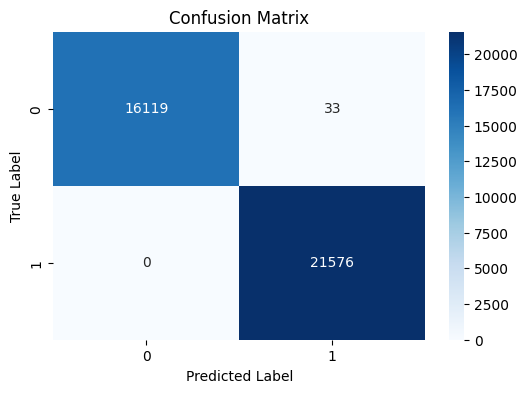


Accuracy: 99.91%
Sensitivity: 100.00%
Specificity: 99.80%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16152
           1       1.00      1.00      1.00     21576

    accuracy                           1.00     37728
   macro avg       1.00      1.00      1.00     37728
weighted avg       1.00      1.00      1.00     37728



In [ ]:
# Train the LR model

# Step 1: Create the model
# We're making a Logistic Regression model
# random_state = 42 ensures we get the same results every time we run it (for reproducibility)
lr_model = LogisticRegression(random_state=42, solver='liblinear') # Added solver for potential convergence issues

# Step 2: Train the model
# We give the model the training data (X_train = input features, y_train = labels like 0 or 1)
# The model learns from this data so it can make predictions later
lr_model.fit(X_train, y_train)

# # Use the previously defined function to evaluate performance on train data (usually not done, but just FYI)
# y_train_pred_lr = lr_model.predict(X_train)
# print("Evaluation on Train Data (Logistic Regression):")
# evaluate_classification_model(y_train, y_train_pred_lr)

# Test the LR Model

# Evaluate the model on the test data
y_test_pred_lr = lr_model.predict(X_test)

# Use the previously defined function to evaluate performance on test data
print("Evaluation on Test Data (Logistic Regression):")
evaluate_classification_model(y_test, y_test_pred_lr)

**2. DECISION TREE (DT)**

Think of a game of 20 Questions. A Decision Tree is similar. It asks a series of "yes" or "no" questions about the data. For example: "Did the patient smoke?" If yes, then "Is their blood pressure high?" Each answer leads down a different branch until it reaches a leaf that gives a final prediction (like "stroke" or "no stroke"). It's easy to follow the "decisions" it makes.

Evaluation on Test Data (Decision Tree):
Confusion Matrix:
[[16144     8]
 [    2 21574]]


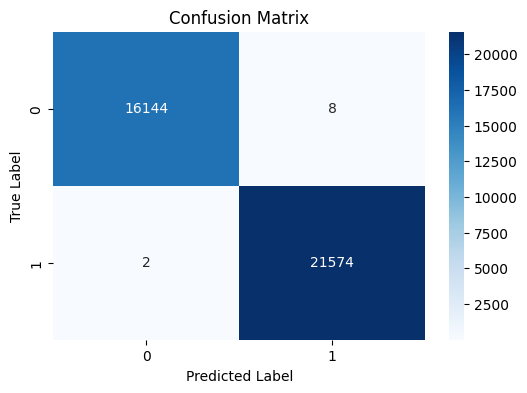


Accuracy: 99.97%
Sensitivity: 99.99%
Specificity: 99.95%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16152
           1       1.00      1.00      1.00     21576

    accuracy                           1.00     37728
   macro avg       1.00      1.00      1.00     37728
weighted avg       1.00      1.00      1.00     37728



In [ ]:
# Train the DT model

# Step 1: Create the model
# We're making a Decision Tree Classifier
# random_state = 42 ensures we get the same results every time we run it (for reproducibility)
dt_model = DecisionTreeClassifier(random_state=42)

# Step 2: Train the model
# We give the model the training data (X_train = input features, y_train = labels like 0 or 1)
# The model learns from this data so it can make predictions later
dt_model.fit(X_train, y_train)

# # Use the previously defined function to evaluate performance on train data (usually not done, but just FYI)
# y_train_pred_dt = dt_model.predict(X_train)
# print("Evaluation on Train Data (Decision Tree):")
# evaluate_classification_model(y_train, y_train_pred_dt)

# Test the DT Model

# Evaluate the model on the test data
y_test_pred_dt = dt_model.predict(X_test)

# Use the previously defined function to evaluate performance on test data
print("Evaluation on Test Data (Decision Tree):")
evaluate_classification_model(y_test, y_test_pred_dt)

**3. RANDOM FOREST (RF)**

A Random Forest builds hundreds of Decision Trees, each trained on slightly different parts of the data. Then, when it needs to make a prediction, all the trees "vote" on the answer. The majority vote wins. This makes it much stronger and more accurate than a single tree, like having a team of experts instead of just one.

Evaluation on Test Data (Random Forest):
Confusion Matrix:
[[16143     9]
 [    0 21576]]


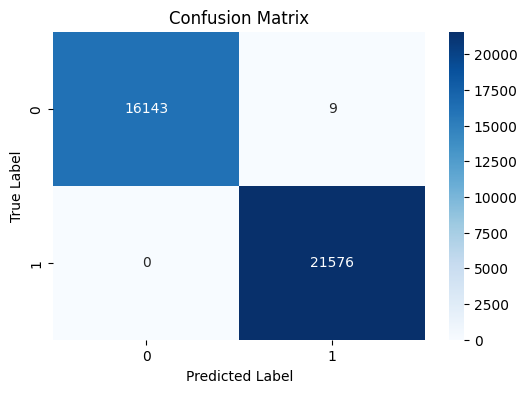


Accuracy: 99.98%
Sensitivity: 100.00%
Specificity: 99.94%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16152
           1       1.00      1.00      1.00     21576

    accuracy                           1.00     37728
   macro avg       1.00      1.00      1.00     37728
weighted avg       1.00      1.00      1.00     37728



In [26]:
# Train the RF model

# Step 1: Create the model
# We're making a Random Forest Classifier with 100 trees (n_estimators=100)
# random_state=42 ensures we get the same results every time we run it (for reproducibility)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Step 2: Train the model
# We give the model the training data (X_train = input features, y_train = labels like 0 or 1)
# The model learns from this data so it can make predictions later
rf_model.fit(X_train, y_train)

# # Use the previously defined function to evaluate performance on train data (usually not done, but just FYI)
# y_train_pred_rf = rf_model.predict(X_train)
# print("Evaluation on Train Data (Random Forest):")
# evaluate_classification_model(y_train, y_train_pred_rf)

# Test the RF Model

# Evaluate the model on the test data
y_test_pred_rf = rf_model.predict(X_test)

# Use the previously defined function to evaluate performance on test data
print("Evaluation on Test Data (Random Forest):")
evaluate_classification_model(y_test, y_test_pred_rf)


**4. SUPPORT VECTOR MACHINE (SVM)**

Imagine placing a line between "stroke" and "no stroke" cases on a graph. SVM finds the best possible line (or curve) that separates the two. An SVM tries to find the best straight line (or "hyperplane" in higher dimensions) that perfectly separates the stroke cases from the no-stroke ones with the widest possible "gap" between them. The cases closest to this line are called "support vectors" and are super important in defining the line.

Evaluation on Test Data (SVM):
Confusion Matrix:
[[20013   176]
 [    0 26970]]


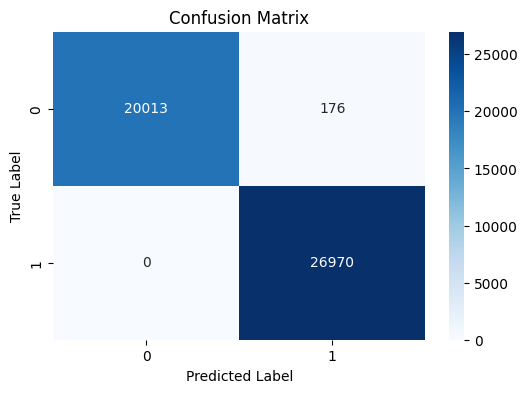


Accuracy: 99.63%
Sensitivity: 100.00%
Specificity: 99.13%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     20189
           1       0.99      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



In [ ]:
# Train the SVM model

# Step 1: Create the model
# We're making a Support Vector Machine (SVC) model
# The 'kernel' parameter determines how the model handles non-linear relationships (rbf is a common choice)
# random_state=42 ensures we get the same results every time we run it (for reproducibility)
svm_model = SVC(kernel='rbf', random_state=42)

# Step 2: Train the model
# We give the model the training data (X_train = input features, y_train = labels like 0 or 1)
# The model learns from this data so it can make predictions later
svm_model.fit(X_train, y_train)

# # Use the previously defined function to evaluate performance on train data (usually not done, but just FYI)
# y_train_pred_svm = svm_model.predict(X_train)
# print("Evaluation on Train Data (SVM):")
# evaluate_classification_model(y_train, y_train_pred_svm)

# Test the SVM Model

# Evaluate the model on the test data
y_test_pred_svm = svm_model.predict(X_test)

# Use the previously defined function to evaluate performance on test data
print("Evaluation on Test Data (SVM):")
evaluate_classification_model(y_test, y_test_pred_svm)

**5. k-NEAREST NEIGHBORS (KNN)**

To predict if a new patient will have a stroke or not, KNN finds the K most similar people in the dataset (based on health info) and sees how many had a stroke. If most of them had a stroke, it predicts you might too.

Evaluation on Train Data (KNN):
Confusion Matrix:
[[18268  1377]
 [ 1132 35223]]


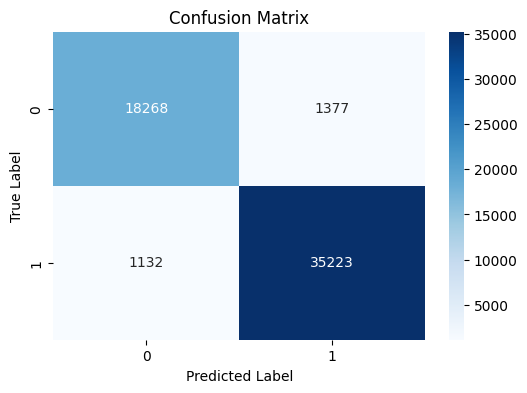


Accuracy: 95.52%
Sensitivity: 96.89%
Specificity: 92.99%

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.94     19645
           1       0.96      0.97      0.97     36355

    accuracy                           0.96     56000
   macro avg       0.95      0.95      0.95     56000
weighted avg       0.96      0.96      0.96     56000

Evaluation on Test Data (KNN):
Confusion Matrix:
[[4315  596]
 [ 547 8542]]


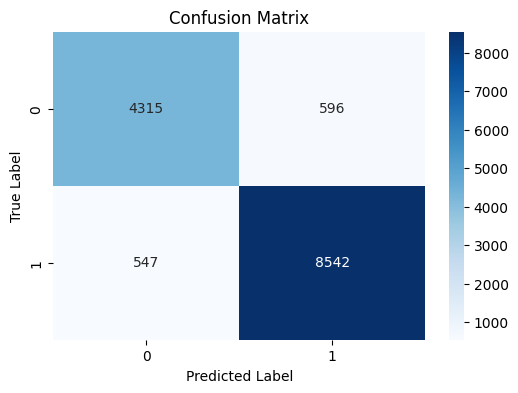


Accuracy: 91.84%
Sensitivity: 93.98%
Specificity: 87.86%

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.88      0.88      4911
           1       0.93      0.94      0.94      9089

    accuracy                           0.92     14000
   macro avg       0.91      0.91      0.91     14000
weighted avg       0.92      0.92      0.92     14000



In [ ]:
# Train the KNN model

# Step 1: Create the model
# We're making a K-Nearest Neighbors Classifier with k=5 (n_neighbors=5)
knn_model = KNeighborsClassifier(n_neighbors=5)

# Step 2: Train the model
# We give the model the training data (X_train = input features, y_train = labels like 0 or 1)
# The model learns from this data so it can make predictions later
knn_model.fit(X_train, y_train)

# Use the previously defined function to evaluate performance on train data (usually not done, but just FYI)
y_train_pred_knn = knn_model.predict(X_train)
print("Evaluation on Train Data (KNN):")
evaluate_classification_model(y_train, y_train_pred_knn)

# Test the KNN Model

# Evaluate the model on the test data
y_test_pred_knn = knn_model.predict(X_test)

# Use the previously defined function to evaluate performance on test data
print("Evaluation on Test Data (KNN):")
evaluate_classification_model(y_test, y_test_pred_knn)


**6. NAIVE BAYES (NB)**

Imagine you want to predict if a patient will have a stroke or not. Naive Bayes would look at different patient features like age, blood pressure, cholesterol levels, and smoking status. It calculates the probability of a patient having a stroke given these features, and the probability of not having a stroke given the same features.

For instance, it might learn:

The probability of a patient having a stroke is higher if they are over 60.
The probability of having a stroke is higher if their blood pressure is high.
The probability of not having a stroke is higher if they don't smoke.

Then, for a new patient, it combines these individual probabilities (assuming they're independent) to see which outcome ("stroke" or "no stroke") is more likely. If the combined probability of "stroke" is higher, it predicts a stroke.

Evaluation on Train Data (Naive Bayes):
Confusion Matrix:
[[17065  2580]
 [ 1649 34706]]


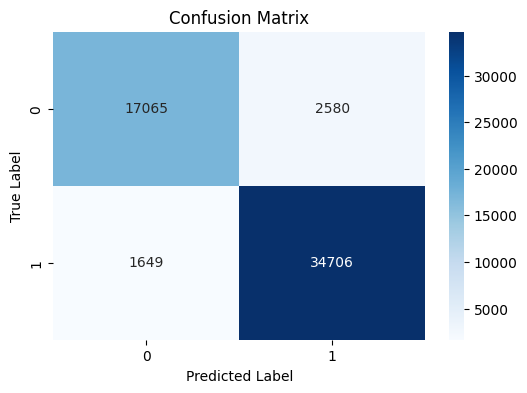


Accuracy: 92.45%
Sensitivity: 95.46%
Specificity: 86.87%

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.87      0.89     19645
           1       0.93      0.95      0.94     36355

    accuracy                           0.92     56000
   macro avg       0.92      0.91      0.92     56000
weighted avg       0.92      0.92      0.92     56000

Evaluation on Test Data (Naive Bayes):
Confusion Matrix:
[[4315  596]
 [ 389 8700]]


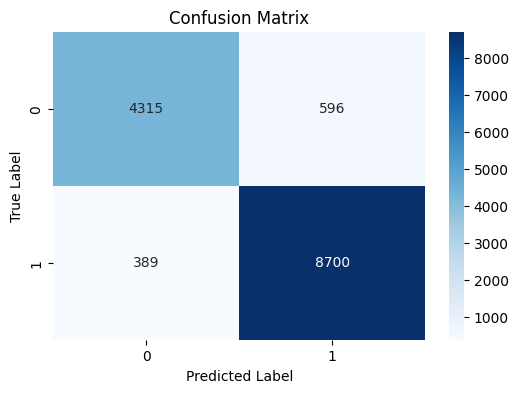


Accuracy: 92.96%
Sensitivity: 95.72%
Specificity: 87.86%

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.88      0.90      4911
           1       0.94      0.96      0.95      9089

    accuracy                           0.93     14000
   macro avg       0.93      0.92      0.92     14000
weighted avg       0.93      0.93      0.93     14000



In [ ]:
# Train the NB model

# Step 1: Create the model
# We're making a Gaussian Naive Bayes model
nb_model = GaussianNB()

# Step 2: Train the model
# We give the model the training data (X_train = input features, y_train = labels like 0 or 1)
# The model learns from this data so it can make predictions later
nb_model.fit(X_train, y_train)

# Use the previously defined function to evaluate performance on train data (usually not done, but just FYI)
y_train_pred_nb = nb_model.predict(X_train)
print("Evaluation on Train Data (Naive Bayes):")
evaluate_classification_model(y_train, y_train_pred_nb)

# Test the NB Model

# Evaluate the model on the test data
y_test_pred_nb = nb_model.predict(X_test)

# Use the previously defined function to evaluate performance on test data
print("Evaluation on Test Data (Naive Bayes):")
evaluate_classification_model(y_test, y_test_pred_nb)

**7. GRADIENT BOOSTING CLASSIFIER (GBC)**

Think of GBC as a team of weak "learners" (like simple decision trees) working together to correct each other's mistakes.

First Learner: A simple decision tree makes an initial prediction for each patient, perhaps predicting "no stroke" for everyone. It will make many mistakes (e.g., predicting "no stroke" for patients who actually had a stroke).

Second Learner: This tree focuses on the patients where the first tree made mistakes, especially those where it was very wrong. It tries to correct those specific errors.

Subsequent Learners: Each new tree in the sequence continues to learn from the residuals (the errors or differences between the actual outcome and the current combined prediction) of the previous trees. They give more attention to the patients who are harder to classify correctly.

Finally, the predictions from all these weak learners are combined to create a very strong, accurate prediction of "stroke" or "no stroke."

Evaluation on Train Data:
Confusion Matrix:
[[19400   245]
 [    1 36354]]


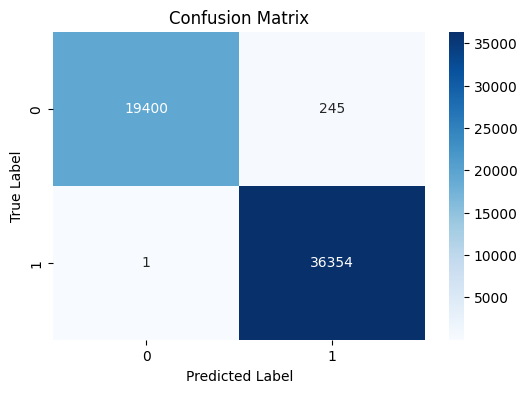


Accuracy: 99.56%
Sensitivity: 100.00%
Specificity: 98.75%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     19645
           1       0.99      1.00      1.00     36355

    accuracy                           1.00     56000
   macro avg       1.00      0.99      1.00     56000
weighted avg       1.00      1.00      1.00     56000

Evaluation on Test Data:
Confusion Matrix:
[[4837   74]
 [   0 9089]]


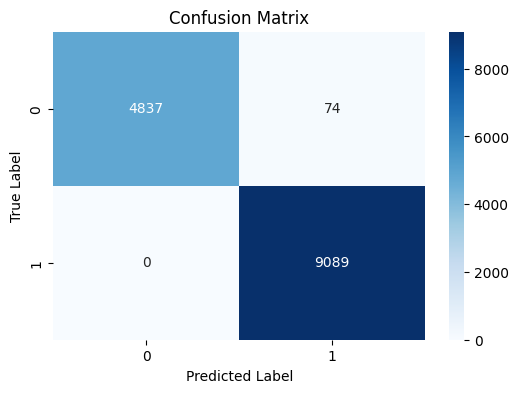


Accuracy: 99.47%
Sensitivity: 100.00%
Specificity: 98.49%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      4911
           1       0.99      1.00      1.00      9089

    accuracy                           0.99     14000
   macro avg       1.00      0.99      0.99     14000
weighted avg       0.99      0.99      0.99     14000



In [ ]:
# Train the GBC model

# Step 1: Create the model
# We're making a Gradient Boosting Classifier with 300 trees (n_estimators = 300)
# random_state = 42 ensures we get the same results every time we run it (for reproducibility)
gbc_model = GradientBoostingClassifier(n_estimators=300, random_state=42)

# Step 2: Train the model
# We give the model the training data (X_train = input features, y_train = labels like 0 or 1) (Remember we prepared the dataset to separate features and target and split it into train and test datasets?)
# The model learns from this data so it can make predictions later
gbc_model.fit(X_train, y_train)

# Use the previously defined function to evaluate performance on train data (usually not done, but just FYI)
y_train_pred = gbc_model.predict(X_train)
print("Evaluation on Train Data:")
evaluate_classification_model(y_train, y_train_pred)

# Test the GBC Model

# Evaluate the model on the test data
y_test_pred = gbc_model.predict(X_test)

# Use the previously defined function to evaluate performance on test data
print("Evaluation on Test Data:")
evaluate_classification_model(y_test, y_test_pred)

**8. XGBoost**

XGBoost is a highly optimized and powerful version of Gradient Boosting. While the core idea is the same as GBC (sequentially correcting errors), XGBoost adds several enhancements that make it faster and more accurate for tasks like stroke prediction.

Regularization: It has mechanisms to prevent the model from becoming too complex and "memorizing" the training data (overfitting). This is like adding a penalty for overly complicated rules, ensuring the model generalizes well to new patients.

Parallel Processing: It can build trees in a way that allows parts of the process to run at the same time, making it much quicker, especially for large datasets.

Handling Missing Values: It has built-in ways to intelligently deal with missing patient data, like if a patient's cholesterol level wasn't recorded.

For a stroke dataset, XGBoost would use patient features to build a series of trees, with each tree refining the predictions of the previous ones, ultimately leading to a very robust "stroke" or "no stroke" classification. It's often a top performer in competitions due to these optimizations.

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:21:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Evaluation on Test Data (XGBoost):
Confusion Matrix:
[[4884   27]
 [  17 9072]]


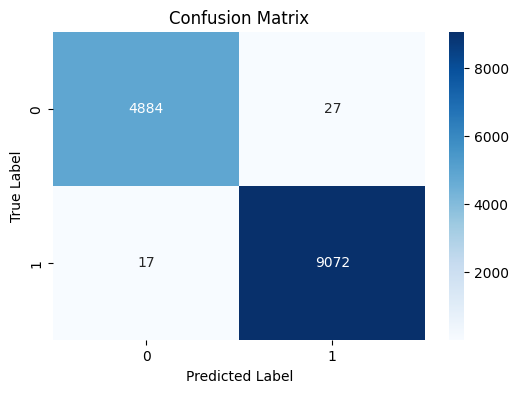


Accuracy: 99.69%
Sensitivity: 99.81%
Specificity: 99.45%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      4911
           1       1.00      1.00      1.00      9089

    accuracy                           1.00     14000
   macro avg       1.00      1.00      1.00     14000
weighted avg       1.00      1.00      1.00     14000



In [ ]:
# Train the XGBoost model

# Step 1: Create the model
# We're making an XGBoost Classifier
# use_label_encoder=False is recommended to avoid a deprecation warning
# eval_metric='logloss' is a common metric for binary classification
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Step 2: Train the model
# We give the model the training data (X_train = input features, y_train = labels like 0 or 1)
# The model learns from this data so it can make predictions later
xgb_model.fit(X_train, y_train)

# # Use the previously defined function to evaluate performance on train data
# y_train_pred_xgb = xgb_model.predict(X_train)
# print("Evaluation on Train Data (XGBoost):")
# evaluate_classification_model(y_train, y_train_pred_xgb)

# Test the XGBoost Model

# Evaluate the model on the test data
y_test_pred_xgb = xgb_model.predict(X_test)

# Use the previously defined function to evaluate performance on test data
print("Evaluation on Test Data (XGBoost):")
evaluate_classification_model(y_test, y_test_pred_xgb)

**9. MLP Neural Network (Multi-Layer Perceptron)**

Imagine a network of "neurons" organized in layers, similar to how your brain processes information.

Input Layer: Each input "neuron" receives a piece of patient information (e.g., age, blood pressure, glucose level, smoking status, BMI).

Hidden Layers: These are the "thinking" layers in between. Each neuron in these layers takes inputs from the previous layer, performs a calculation, and passes its output to the next layer. These layers learn complex, non-linear relationships between the patient features that might not be obvious to simpler models. For example, it might learn that the combination of high blood pressure AND high glucose at a certain age strongly indicates stroke risk.

Output Layer: The final layer has one or two neurons that produce the prediction. For binary classification, it often outputs a probability (e.g., a single neuron outputting a value between 0 and 1, where values closer to 1 mean higher probability of "stroke"). If the probability is above a certain threshold (e.g., 0.5), it classifies as "stroke"; otherwise, "no stroke."

During training, the network adjusts the "strength" of the connections (called weights) between neurons based on whether its predictions were correct. This continuous adjustment helps the MLP learn the best way to classify patients as "stroke" or "no stroke."

Evaluation on Train Data (MLP Neural Network):
Confusion Matrix:
[[19282   363]
 [    0 36355]]


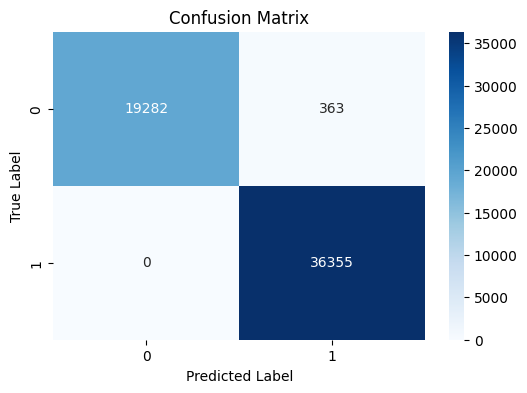


Accuracy: 99.35%
Sensitivity: 100.00%
Specificity: 98.15%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     19645
           1       0.99      1.00      1.00     36355

    accuracy                           0.99     56000
   macro avg       1.00      0.99      0.99     56000
weighted avg       0.99      0.99      0.99     56000

Evaluation on Test Data (MLP Neural Network):
Confusion Matrix:
[[4802  109]
 [   0 9089]]


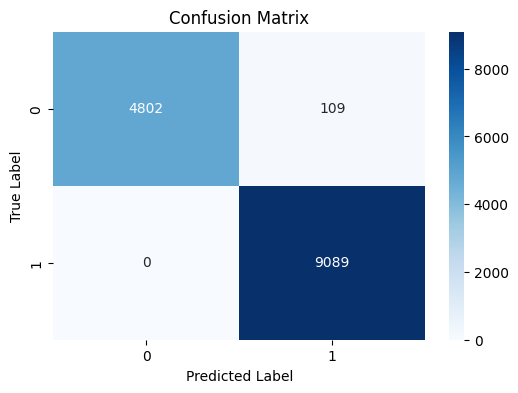


Accuracy: 99.22%
Sensitivity: 100.00%
Specificity: 97.78%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      4911
           1       0.99      1.00      0.99      9089

    accuracy                           0.99     14000
   macro avg       0.99      0.99      0.99     14000
weighted avg       0.99      0.99      0.99     14000



In [ ]:
# Train the MLP model

# Step 1: Create the model
# We're making an MLPClassifier
# hidden_layer_sizes=(100,) means one hidden layer with 100 neurons. You can add more layers and neurons, e.g., (100, 50)
# max_iter controls the number of training epochs
# random_state=42 ensures reproducibility
# activation='relu' is a common activation function
# solver='adam' is a common optimizer
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42, activation='relu', solver='adam')

# Step 2: Train the model
# We give the model the training data (X_train = input features, y_train = labels like 0 or 1)
# The model learns from this data so it can make predictions later
# It's a good practice to scale data for MLP, but we'll skip that for this basic example
mlp_model.fit(X_train, y_train)

# Use the previously defined function to evaluate performance on train data (usually not done, but just FYI)
y_train_pred_mlp = mlp_model.predict(X_train)
print("Evaluation on Train Data (MLP Neural Network):")
evaluate_classification_model(y_train, y_train_pred_mlp)

# Test the MLP Model

# Evaluate the model on the test data
y_test_pred_mlp = mlp_model.predict(X_test)

# Use the previously defined function to evaluate performance on test data
print("Evaluation on Test Data (MLP Neural Network):")
evaluate_classification_model(y_test, y_test_pred_mlp)

## Finding the important features

In [ ]:
X_train.columns

Index(['URLSimilarityIndex', 'SpacialCharRatioInURL', 'IsHTTPS',
       'DomainTitleMatchScore', 'URLTitleMatchScore', 'IsResponsive',
       'HasDescription', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields',
       'HasCopyrightInfo'],
      dtype='object')

In [ ]:
# 1. Global Feature Importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("Top 10 Important Features:")
print(feature_importance.head(10))

Top 10 Important Features:
                  feature  importance
0      URLSimilarityIndex    0.415458
7            HasSocialNet    0.238214
10       HasCopyrightInfo    0.115101
6          HasDescription    0.088651
2                 IsHTTPS    0.045305
3   DomainTitleMatchScore    0.045165
8         HasSubmitButton    0.025712
1   SpacialCharRatioInURL    0.011365
4      URLTitleMatchScore    0.007567
9         HasHiddenFields    0.004678


In [ ]:
!pip install shap

In [ ]:
import shap
# -----------------------------
# 1. Create SHAP Explainer
# -----------------------------
explainer = shap.Explainer(rf_model, X_train)

In [ ]:
# -----------------------------
# 2. Pick a sample to explain
# -----------------------------
sample = X_val.iloc[[100]]

# -----------------------------
# 3. Get prediction
# -----------------------------
pred = rf_model.predict(sample)[0]
print("Prediction:", "Legitimate" if pred == 1 else "Phishing")
sample

Prediction: Phishing


,URLSimilarityIndex,SpacialCharRatioInURL,IsHTTPS,DomainTitleMatchScore,URLTitleMatchScore,IsResponsive,HasDescription,HasSocialNet,HasSubmitButton,HasHiddenFields,HasCopyrightInfo
54097,22.050565,0.139,0,0.0,0.0,1,0,0,1,1,1


In [ ]:
# -----------------------------
# 4. Compute SHAP values
# -----------------------------
shap_values = explainer(sample)
shap_values

.values =
array([[[ 3.80731974e-01, -3.80731978e-01],
        [-3.33376049e-05,  3.33373904e-05],
        [ 1.48827455e-01, -1.48827457e-01],
        [ 4.88810486e-03, -4.88810497e-03],
        [-3.56639878e-03,  3.56639880e-03],
        [-4.04920638e-04,  4.04920602e-04],
        [ 1.41394138e-03, -1.41394093e-03],
        [ 1.65290612e-02, -1.65290589e-02],
        [-4.29952807e-03,  4.29952780e-03],
        [-3.64373453e-03,  3.64373419e-03],
        [-3.42623171e-04,  3.42623137e-04]]])

.base_values =
array([[0.4599, 0.5401]])

.data =
array([[22.05056482,  0.139     ,  0.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  0.        ,  1.        ,  1.        ,
         1.        ]])

In [ ]:
# -----------------------------
# 5. Extract SHAP values for this single example (1D array of feature contributions)

# SHAP returns contributions for each feature, but the shape can vary depending on the model
# If it is (1, num_features), we already have one set of contributions → take the first row
# If it is (1, num_features, 2), it means contributions are given for both classes → we pick class 1 (legitimate)

# -----------------------------
vals = shap_values.values

# Case 1: (1, num_features)
if len(vals.shape) == 2:
    shap_vals = vals[0]

# Case 2: (1, num_features, 2)
elif len(vals.shape) == 3:
    shap_vals = vals[0, :, 1]  # class 1 = legitimate

else:
    raise ValueError("Unexpected SHAP shape:", vals.shape)

print("shap_vals:", shap_vals)

# Feature values - Get the actual feature values for this sample (used to show alongside SHAP explanations)
feature_vals = sample.iloc[0].values
print("feature_vals:", feature_vals)


shap_vals: [-3.80731978e-01  3.33373904e-05 -1.48827457e-01 -4.88810497e-03
  3.56639880e-03  4.04920602e-04 -1.41394093e-03 -1.65290589e-02
  4.29952780e-03  3.64373419e-03  3.42623137e-04]
feature_vals: [22.05056482  0.139       0.          0.          0.          1.
  0.          0.          1.          1.          1.        ]


In [ ]:
# -----------------------------
# 6. Create explanation dataframe
# -----------------------------
shap_df = pd.DataFrame({
    "feature": X_train.columns,
    "value": feature_vals,
    "shap_value": shap_vals
})

# Sort by impact
shap_df["abs_shap"] = np.abs(shap_df["shap_value"])
shap_df = shap_df.sort_values(by="abs_shap", ascending=False)

print("\nTop Feature Contributions:")
print(shap_df.head(10))


Top Feature Contributions:
                  feature      value  shap_value  abs_shap
0      URLSimilarityIndex  22.050565   -0.380732  0.380732
2                 IsHTTPS   0.000000   -0.148827  0.148827
7            HasSocialNet   0.000000   -0.016529  0.016529
3   DomainTitleMatchScore   0.000000   -0.004888  0.004888
8         HasSubmitButton   1.000000    0.004300  0.004300
9         HasHiddenFields   1.000000    0.003644  0.003644
4      URLTitleMatchScore   0.000000    0.003566  0.003566
6          HasDescription   0.000000   -0.001414  0.001414
5            IsResponsive   1.000000    0.000405  0.000405
10       HasCopyrightInfo   1.000000    0.000343  0.000343


In [ ]:
# -----------------------------
# 7. Human-readable explanation

# This function turns SHAP values into simple English explanations
# It looks at the top features that influenced the prediction the most

# For each important feature:
# - "impact" tells us if it pushed the prediction toward phishing or legitimate
# - We label the effect as "strong" or "slight" based on how big the impact is

# If the prediction is legitimate:
# - Positive impact → supports legitimacy
# - Negative impact → raises suspicion

# If the prediction is phishing:
# - Negative impact → supports phishing
# - Positive impact → indicates legitimacy (but not enough to change the final decision)

# The output is a list of easy-to-understand reasons for the prediction
# -----------------------------
def generate_explanations(shap_df, prediction, top_n=3):
    explanations = []

    top = shap_df.head(top_n)

    for _, row in top.iterrows():
        feature = row["feature"]
        value = row["value"]
        impact = row["shap_value"]

        strength = "strongly" if abs(impact) > 0.05 else "slightly"

        if prediction == 1:  # Legitimate
            if impact > 0:
                explanations.append(f"{feature} {strength} supports legitimacy (value={round(value,2)})")
            else:
                explanations.append(f"{feature} {strength} raises suspicion (value={round(value,2)})")

        else:  # Phishing
            if impact < 0:
                explanations.append(f"{feature} {strength} supports phishing (value={round(value,2)})")
            else:
                explanations.append(f"{feature} {strength} indicates legitimacy (value={round(value,2)})")

    return explanations

In [ ]:
# -----------------------------
# 8. Print explanations
# -----------------------------
explanations = generate_explanations(shap_df, pred)

print("\nTop Reasons:")
for e in explanations:
    print("-", e)


Top Reasons:
- URLSimilarityIndex strongly supports phishing (value=22.05)
- IsHTTPS strongly supports phishing (value=0.0)
- HasSocialNet slightly supports phishing (value=0.0)


In [ ]:
# -----------------------------
# ONE SINGLE CODE: Plugin-ready output (JSON)
# -----------------------------
def predict_with_explanation(sample):
    shap_values = explainer(sample)
    vals = shap_values.values

    if len(vals.shape) == 2:
        shap_vals = vals[0]
    elif len(vals.shape) == 3:
        shap_vals = vals[0, :, 1]

    shap_df = pd.DataFrame({
        "feature": X_train.columns,
        "value": sample.iloc[0].values,
        "shap_value": shap_vals
    })

    shap_df["abs_shap"] = np.abs(shap_df["shap_value"])
    shap_df = shap_df.sort_values(by="abs_shap", ascending=False)

    pred = rf_model.predict(sample)[0]
    explanations = generate_explanations(shap_df, pred)

    return {
        "prediction": "legitimate" if pred == 1 else "phishing",
        "reasons": explanations
    }

# -----------------------------
# Get a user input on sample number
# -----------------------------
sample = input("Please enter a sample number in the validation dataset to test (Try 100 for a phishing URL):  ")
val_user_data = X_val.iloc[[sample]]
result = predict_with_explanation(val_user_data)

print("\nOutput:")
print(result)

Please enter a sample number in the validation dataset to test (Try 100 for a phishing URL):  100

Output:
{'prediction': 'phishing', 'reasons': ['URLSimilarityIndex strongly supports phishing (value=22.05)', 'IsHTTPS strongly supports phishing (value=0.0)', 'HasSocialNet slightly supports phishing (value=0.0)']}


In [30]:
list(X_train.columns)

['URLSimilarityIndex',
 'SpacialCharRatioInURL',
 'IsHTTPS',
 'DomainTitleMatchScore',
 'URLTitleMatchScore',
 'IsResponsive',
 'HasDescription',
 'HasSocialNet',
 'HasSubmitButton',
 'HasHiddenFields',
 'HasCopyrightInfo']

In [31]:
import pickle

# Save model
with open("rf_model.pkl","wb") as f:
  pickle.dump(rf_model,f)

# Save feature names
with open("feature_names.pkl","wb") as f:
  pickle.dump(list(X_train.columns),f)

